# Kalman Filter Exercise (Constant-Velocity Model)

This notebook simulates a 1D target with constant velocity and random acceleration, applies a Kalman filter, and visualizes:
- True vs measured vs filtered position
- True vs filtered velocity
- Innovation over time

We can modify `sigma_a` (process noise) and `sigma_y` (measurement noise) and re-run to see how the filter reacts.


## Idea and Matrix Formulations

### 1) State and kinematics ⇒ $A,B$

We choose the state

$$
x_t=\begin{bmatrix}p_t\\ v_t\end{bmatrix}
$$

(position, velocity). Over a small time step $\Delta t$, basic kinematics give

$$
\begin{aligned}
p_{t+1} &= p_t + v_t\,\Delta t + \tfrac{1}{2}\,a_t\,\Delta t^2,\\
v_{t+1} &= v_t + a_t\,\Delta t,
\end{aligned}
$$

where $a_t$ is acceleration during the step.

If we split acceleration into a **known input** $u_t$ (e.g., commanded accel) and **unknown disturbance** (handled in $Q$ below), the state update can be written

$$
x_{t+1}=A x_t + B u_t + \text{(process noise)},
$$

with

$$
A=\begin{bmatrix}1&\Delta t\\[2pt]0&1\end{bmatrix},\qquad
B=\begin{bmatrix}\tfrac{1}{2}\Delta t^2\\[2pt]\Delta t\end{bmatrix}.
$$


### 2) What the sensor sees ⇒ $C$

The notebook measures **position only**:

$$
y_t = p_t + \text{noise} \quad\Rightarrow\quad
C=\begin{bmatrix}1&0\end{bmatrix}.
$$


### 3) How unpredictable the dynamics are ⇒ $Q$

We assume **random acceleration** (unmodeled bumps, wind) with zero mean and variance $\sigma_a^2$. In continuous time this is “white acceleration noise.” When you integrate that noise over a step $\Delta t$, it induces correlated uncertainty in both position and velocity. The discrete-time process noise covariance works out to

$$
Q=\sigma_a^2\begin{bmatrix}
\tfrac{1}{4}\Delta t^4 & \tfrac{1}{2}\Delta t^3\\[4pt]
\tfrac{1}{2}\Delta t^3 & \Delta t^2
\end{bmatrix}.
$$

Where does it come from? From the standard discretization formula

$$
Q_d=\int_0^{\Delta t} e^{F\tau}G\,\sigma_a^2\,G^\top e^{F^\top\tau}\,d\tau,
$$

with the $F,G$ above; evaluating the integral gives the powers of $\Delta t$.

**Practical meaning:** larger $\sigma_a\Rightarrow$ larger $Q\Rightarrow$ the filter trusts the *model* less and reacts more to measurements.


### 4) How noisy the sensor is ⇒ $R$

If your position sensor has standard deviation $\sigma_y$, then

$$
R=\begin{bmatrix}\sigma_y^2\end{bmatrix}.
$$

Multiple sensors → $R$ is an $m\times m$ covariance across their noises.

**Practical meaning:** larger $\sigma_y\Rightarrow$ larger $R\Rightarrow$ the filter trusts the *sensor* less and smooths more.


### 5) Prior belief ⇒ $\hat x_{0|0}, P_{0|0}$

* $\hat x_{0|0}$ is your initial best guess (we used $[0,0]$ to be agnostic about velocity).
* $P_{0|0}$ is how uncertain you are (we used a big diagonal like $\mathrm{diag}(100,100)$ to say “very unsure”).

Big $P_0$ makes the filter learn quickly from early measurements; tiny $P_0$ makes it stubborn.


### 6) Innovation statistics & numerics ⇒ $S_t, K_t$, Joseph form

Given the **prediction covariance** $P_{t|t-1}$,

$$
S_t = C P_{t|t-1} C^\top + R
$$

is the variance of the **innovation** $\tilde y_t = y_t - C\hat x_{t|t-1}$. The Kalman **gain**

$$
K_t = P_{t|t-1} C^\top S_t^{-1}
$$

weights how much to correct the prediction with the innovation.

We update covariance with the **Joseph form**

$$
P_{t|t} = (I-K_t C)P_{t|t-1}(I-K_t C)^\top + K_t R K_t^\top,
$$

which preserves symmetry/positive semidefiniteness better in finite precision.


### Additional details

Let $A\in\mathbb R^{n\times n},\,C\in\mathbb R^{m\times n}$.

* Prior (a.k.a. prediction) at time $t$: $\hat x_{t|t-1}$, covariance $P_{t|t-1}\in\mathbb R^{n\times n}$.
* Measurement: $y_t = Cx_t + w_t$, with $w_t\sim\mathcal N(0,R)$, $R\in\mathbb R^{m\times m}$.
* **Prediction error:** $e_t^- \equiv x_t - \hat x_{t|t-1}$, so $\mathrm{cov}(e_t^-)=P_{t|t-1}$.
* **Innovation (residual):**

$$
\tilde y_t \equiv y_t - C\hat x_{t|t-1} = C(x_t-\hat x_{t|t-1}) + w_t = C e_t^- + w_t .
$$

Assume $e_t^-$ is independent of $w_t$ (true for the Kalman prediction step).

#### Innovation covariance $S_t$

$$
\begin{aligned}
S_t 
&= \mathrm{cov}(\tilde y_t) 
= \mathrm{cov}(C e_t^- + w_t) \\
&= C\,\mathrm{cov}(e_t^-)\,C^\top + \mathrm{cov}(w_t) 
= C P_{t|t-1} C^\top + R.
\end{aligned}
$$

**Meaning:** $S_t$ tells you how uncertain you expect the residual to be, combining (i) how uncertain your prediction is when mapped into measurement space ($C P^- C^\top$) and (ii) sensor noise $R$.

Two handy uses:

* **Whitening / consistency:** $z_t \equiv S_t^{-1/2}\tilde y_t \sim \mathcal N(0,I_m)$ under perfect modeling. The scalar $\tilde y_t^\top S_t^{-1} \tilde y_t$ is the **NIS** (Normalized Innovation Squared) and should behave like $\chi^2_m$.
* **Likelihood:** the per-step log-likelihood of the measurement is

$$
\ell_t = -\tfrac12\Big(\log\!\det S_t + \tilde y_t^\top S_t^{-1}\tilde y_t + m\log 2\pi\Big).
$$

#### Optimal gain $K_t$

We update the mean linearly with the innovation:

$$
\hat x_{t|t} = \hat x_{t|t-1} + K_t\,\tilde y_t,
\quad K_t\in\mathbb R^{n\times m}.
$$

Posterior error:

$$
e_t^+ \equiv x_t - \hat x_{t|t}
= (I - K_t C)\,e_t^- - K_t w_t .
$$

Posterior covariance (take expectations):

$$
\boxed{\,P_{t|t} 
= (I-K_t C) P_{t|t-1} (I-K_t C)^\top + K_t R K_t^\top\,}
$$

This is the **Joseph form** (derived directly from the error expression).

Choose $K_t$ to minimize any sensible measure of posterior uncertainty, e.g. $\mathrm{tr}(P_{t|t})$. Differentiating and setting to zero yields

$$
\boxed{\,K_t = P_{t|t-1} C^\top \big(C P_{t|t-1} C^\top + R\big)^{-1}
= P_{t|t-1} C^\top S_t^{-1}\, }.
$$

**Intuition from extremes:**

* If the sensor is very noisy $R\to\infty\Rightarrow S_t$ large $\Rightarrow K_t\to 0$: trust the model.
* If the prediction is very uncertain $P_{t|t-1}$ large $\Rightarrow K_t$ large: trust the data.

> **Numerics tip:** never form $S_t^{-1}$ explicitly. Compute $K_t$ by solving $S_t X = (C P_{t|t-1})$ for $X^\top$ (e.g., Cholesky of $S_t$).

#### Why the **Joseph form** matters

You’ll also see the compact update

$$
P_{t|t} = (I-K_t C)\,P_{t|t-1}.
$$

This identity **is algebraically equivalent** to the Joseph form **when** $K_t$ is the Kalman gain above (the cross-terms cancel using $K_t S_t = P_{t|t-1} C^\top$).
However, in finite precision this compact form can:

* lose symmetry ($P\neq P^\top$ due to roundoff),
* and even produce slightly negative variances (loss of PSD).

The Joseph form

$$
\boxed{\,P_{t|t} = (I-K_t C)P_{t|t-1}(I-K_t C)^\top + K_t R K_t^\top\,}
$$

explicitly adds the $K R K^\top$ term and keeps $P_{t|t}$ symmetric positive semidefinite numerically. That’s why the notebook uses it.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple

%matplotlib inline

In [2]:
@dataclass
class CVParams:
    dt: float = 0.1
    T: int = 200
    sigma_a: float = 0.5  # process std (random acceleration)
    sigma_y: float = 5.0  # measurement std
    u: float = 0.0  # constant input acceleration

def simulate_constant_velocity(params: CVParams):
    dt = params.dt
    T = params.T
    sigma_a = params.sigma_a
    sigma_y = params.sigma_y
    u = params.u

    A = np.array([[1.0, dt],
                  [0.0, 1.0]])
    B = np.array([[0.5 * dt**2],
                  [dt]])
    C = np.array([[1.0, 0.0]])

    rng = np.random.default_rng(42)
    a_noise = rng.normal(0.0, sigma_a, size=T)
    w = rng.normal(0.0, sigma_y, size=T)

    x = np.zeros((2, T))
    y = np.zeros(T)

    x[:, 0] = np.array([0.0, 10.0])
    y[0] = C @ x[:, 0] + w[0]

    for t in range(1, T):
        x[:, t] = A @ x[:, t-1] + B.flatten() * (u + a_noise[t-1])
        y[t] = (C @ x[:, t]) + w[t]

    return x, y, (A, B, C)

In [3]:
@dataclass
class KFParams:
    A: np.ndarray
    B: np.ndarray
    C: np.ndarray
    Q: np.ndarray
    R: np.ndarray
    x0: np.ndarray
    P0: np.ndarray

def kalman_filter(y: np.ndarray, U: np.ndarray, pars: KFParams):
    T = y.shape[0]
    n = pars.A.shape[0]
    m = pars.C.shape[0]

    x_pred = np.zeros((T, n))
    x_filt = np.zeros((T, n))
    P_pred = np.zeros((T, n, n))
    P_filt = np.zeros((T, n, n))
    K_hist = np.zeros((T, n, m))
    S_hist = np.zeros((T, m, m))
    innov = np.zeros((T, m))

    x_filt[0] = pars.x0
    P_filt[0] = pars.P0

    x_pred[0] = pars.A @ x_filt[0] + pars.B @ U[0]
    P_pred[0] = pars.A @ P_filt[0] @ pars.A.T + pars.Q
    S_hist[0] = pars.C @ P_pred[0] @ pars.C.T + pars.R
    innov[0] = y[0] - (pars.C @ x_pred[0])
    K_hist[0] = P_pred[0] @ pars.C.T @ np.linalg.inv(S_hist[0])

    I = np.eye(n)
    x_filt[0] = x_pred[0] + (K_hist[0] @ innov[0])
    P_filt[0] = (I - K_hist[0] @ pars.C) @ P_pred[0] @ (I - K_hist[0] @ pars.C).T + K_hist[0] @ pars.R @ K_hist[0].T

    for t in range(1, T):
        x_pred[t] = pars.A @ x_filt[t-1] + pars.B @ U[t-1]
        P_pred[t] = pars.A @ P_filt[t-1] @ pars.A.T + pars.Q
        S_hist[t] = pars.C @ P_pred[t] @ pars.C.T + pars.R
        innov[t] = y[t] - (pars.C @ x_pred[t])
        K_hist[t] = P_pred[t] @ pars.C.T @ np.linalg.inv(S_hist[t])
        x_filt[t] = x_pred[t] + (K_hist[t] @ innov[t])
        P_filt[t] = (I - K_hist[t] @ pars.C) @ P_pred[t] @ (I - K_hist[t] @ pars.C).T + K_hist[t] @ pars.R @ K_hist[t].T

    return x_pred, x_filt, P_pred, P_filt, K_hist, innov, S_hist


Position RMSE: 1.558 m
Velocity RMSE: 2.564 m/s
Approx steady-state K (last 20 steps):
 [[0.04376607]
 [0.00979125]]


/var/folders/pn/y6zh5gpn3rs_kj7p71jpmybh0000gn/T/ipykernel_10951/3594490445.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[0] = C @ x[:, 0] + w[0]
/var/folders/pn/y6zh5gpn3rs_kj7p71jpmybh0000gn/T/ipykernel_10951/3594490445.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[t] = (C @ x[:, t]) + w[t]


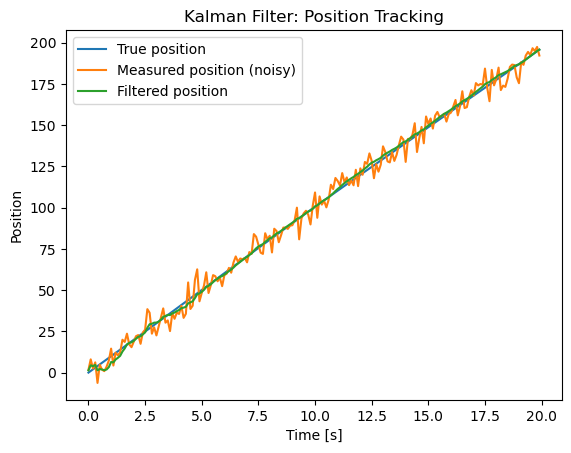

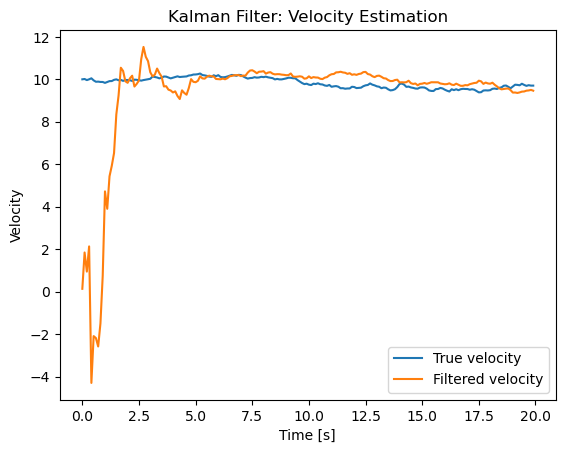

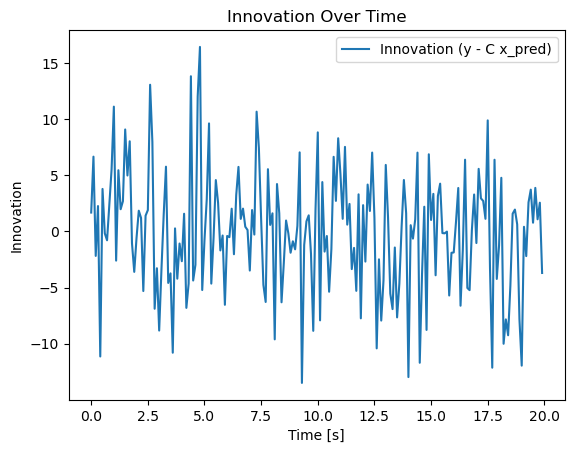

In [4]:
# --- Parameters ---
params = CVParams(dt=0.1, T=200, sigma_a=0.5, sigma_y=5.0, u=0.0)
x_true, y_meas, (A, B, C) = simulate_constant_velocity(params)

dt = params.dt
sigma_a = params.sigma_a
sigma_y = params.sigma_y

Q = (sigma_a**2) * np.array([[0.25*dt**4, 0.5*dt**3],
                             [0.5*dt**3,      dt**2]])
R = np.array([[sigma_y**2]])

x0 = np.array([0.0, 0.0])
P0 = np.diag([100.0, 100.0])

U = np.zeros((params.T, 1))

kf_pars = KFParams(A=A, B=B, C=C, Q=Q, R=R, x0=x0, P0=P0)
x_pred, x_filt, P_pred, P_filt, K_hist, innov, S_hist = kalman_filter(y_meas.reshape(-1,1), U, kf_pars)

# RMSEs
pos_rmse = math.sqrt(np.mean((x_filt[:, 0] - x_true[0])**2))
vel_rmse = math.sqrt(np.mean((x_filt[:, 1] - x_true[1])**2))
print(f"Position RMSE: {pos_rmse:.3f} m\nVelocity RMSE: {vel_rmse:.3f} m/s")
print("Approx steady-state K (last 20 steps):\n", np.mean(K_hist[-20:], axis=0))

# Plots
t = np.arange(params.T) * params.dt

plt.figure()
plt.plot(t, x_true[0], label='True position')
plt.plot(t, y_meas, label='Measured position (noisy)')
plt.plot(t, x_filt[:, 0], label='Filtered position')
plt.xlabel('Time [s]')
plt.ylabel('Position')
plt.title('Kalman Filter: Position Tracking')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, x_true[1], label='True velocity')
plt.plot(t, x_filt[:, 1], label='Filtered velocity')
plt.xlabel('Time [s]')
plt.ylabel('Velocity')
plt.title('Kalman Filter: Velocity Estimation')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, innov[:, 0], label='Innovation (y - C x_pred)')
plt.xlabel('Time [s]')
plt.ylabel('Innovation')
plt.title('Innovation Over Time')
plt.legend()
plt.show()
